# Imports

In [2]:
%reload_ext autoreload
%autoreload 2
import seaborn as sns
import anndata as ad 
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import numpy as np
from scipy.sparse import csr_matrix
import sys
from tqdm import tqdm

sys.path.insert(0, '../')
from task_grn_inference.src.utils.util import colors_blind
from task_grn_inference.src.exp_analysis.helper import Exp_analysis, plot_interactions, create_interaction_info, create_interaction_df, jaccard_similarity_net, cosine_similarity_net, calculate_feature_distance, plot_cumulative_density
from task_grn_inference.src.utils.util import basic_qc, read_gmt

from src.helper import exp_plots

cell_type_mapping = {
    "CD4Naive": "CD4+ T cells",
    "CD4TCM": "CD4+ T cells",
    "CD4TEM": "CD4+ T cells",
    "CD4CTL": "CD4+ T cells",
    "Treg": "CD4+ T cells",
    "CD4Proliferating": "CD4+ T cells",
    "CD8Naive": "CD8+ T cells",
    "CD8TCM": "CD8+ T cells",
    "CD8TEM": "CD8+ T cells",
    "TRAV1-2- CD8+ T cells": "CD8+ T cells",
    "CD8Proliferating": "CD8+ T cells",
    "NK": "NK cells",
    "NK_CD56bright": "NK cells",
    "NKProliferating": "NK cells",
    "Bnaive": "B cells",
    "Bmemory": "B cells",
    "Bintermediate": "B cells",
    "Plasmablast": "B cells",
    "CD14Mono": "Myeloid cells",
    "CD16Mono": "Myeloid cells",
    "cDC1": "Myeloid cells",
    "cDC2": "Myeloid cells",
    "pDC": "Myeloid cells",
    "ASDC": "Myeloid cells",
    "gdT": "gd T cells",
    "MAIT": "MAIT cells",
    "HSPC": "Progenitor cells",
    "Platelet": "Platelet",
    "Eryth": "Erythroid cells",
    "ILC": "ILC",
    "Doublet": "Doublet",
    "dnT": "DN T cells",
    "DN T cells": "DN T cells"
}

ImportError: cannot import name 'exp_plots' from 'src.helper' (/home/jnourisa/projs/ongoing/ciim/src/helper.py)

#TODO: lower down filtering criteria to include more samples from dataset 1

# Dataset 1

## Selection and quality control

In [2]:

par = {
'save_dir' : 'input/full'
}
# - read obs
obs = pd.read_csv('/vol/projects/CIIM/Healthy_Single_Cell_Data/initial_data_downloaded/pbmc_ageing/all_pbmcs/all_pbmcs_metadata.csv', index_col=0)

obs = obs[['Batch', 'Donor_id','Age','Cluster_names', 'Sex']]
obs.columns = ['batch', 'donor_id', 'age', 'cell_type', 'sex']
obs['age_donor'] = obs['age'].astype(str) + '_' + obs['donor_id']

# - remove age over 75
obs = obs[obs.age<=75]

# - binarize to age groups 
bins = [23, 35, 45, 55, 65, 76]  # Define bins for age groups
age_groups = ['34-', '35_44', '45_54', '55_64', '65_75']  # Define corresponding labels
obs['age_group'] = pd.cut(obs['age'], bins=bins, labels=age_groups, right=False)


In [3]:
cell_count_t = 1000

# - filter samples with low cell counts
sample_size = obs.groupby('age_donor', as_index=False).size()
sample_size = sample_size[sample_size['size']>cell_count_t]

obs = obs[obs.age_donor.isin(sample_size.age_donor)]

# - filter for sex 
obs = obs[obs['sex']=='Male']

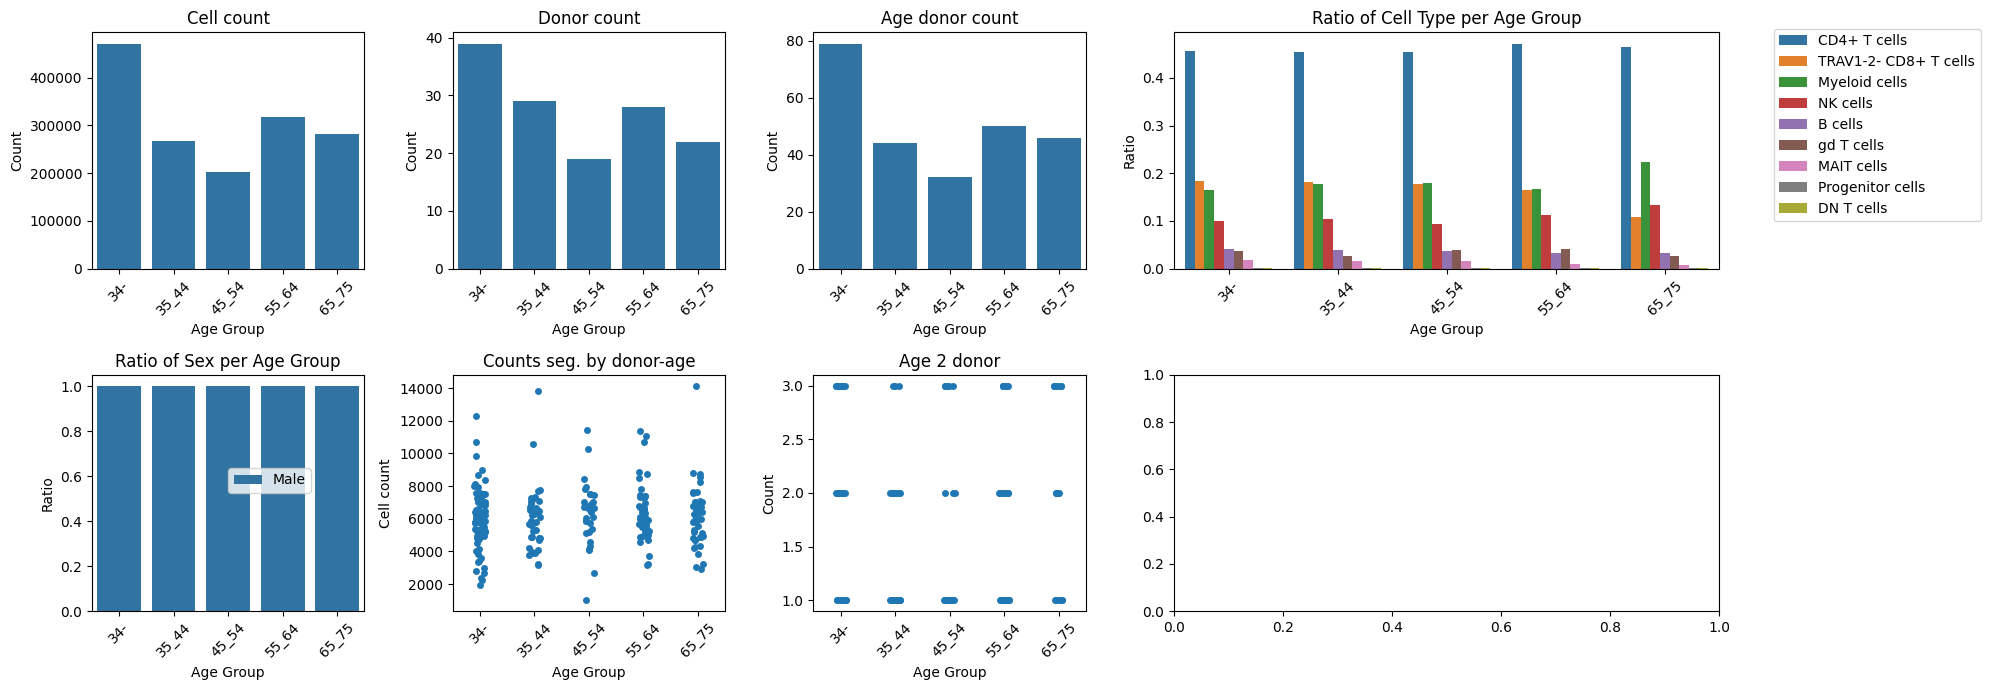

In [4]:
exp_plots(obs.groupby('age_group'))

In [5]:
if False: # define age donor groups
    # - stratified sampling with boostraping 
    from sklearn.model_selection import StratifiedGroupKFold

    min_cells = obs.groupby('age_donor').size().min()

    def stratified_sample_multiple_times(group, sample_size):
        cell_counts = group['cell_type'].value_counts()
        total_cells = len(group)
        samples = []
        
        # Determine how many 4000-cell samples can be drawn
        num_full_samples = total_cells // sample_size
        remaining_cells = total_cells % sample_size  # Remaining cells after full sample extractions
        
        def stratified_sample(group, target_count, replace=False):
            # Same stratified sampling as before
            cell_counts = group['cell_type'].value_counts()
            proportions = cell_counts / cell_counts.sum()
            samples = (proportions * target_count).round().astype(int)
            samples = samples[samples > 0]
            
            sampled_data = []
            for cell_type, n_samples in samples.items():
                sampled_data.append(group[group['cell_type'] == cell_type].sample(n=n_samples, replace=replace))
            return pd.concat(sampled_data)

        # Sample full sets of 4000 cells
        i = 0
        for _ in range(num_full_samples):
            sampled_data = stratified_sample(group, sample_size)
            sampled_data['sample'] = sampled_data['age_donor']+f'_{i}'
            samples.append(sampled_data)
            group = group.drop(sampled_data.index)  # Drop the sampled cells to avoid resampling them
            i+=1
        # print(total_cells, len(samples))
        
        # Sample the remaining cells if any
        # print(sampled_data,remaining_cells)
        if remaining_cells >= sample_size:
            sampled_data = group
            sampled_data['sample'] = sampled_data['age_donor']+f'_{i}'
            samples.append(sampled_data)
        
        return pd.concat(samples)

    obs = obs.groupby('age_donor').apply(lambda x: stratified_sample_multiple_times(x, sample_size=cell_count_t)).reset_index(level=0, drop=True)
    obs['age_donor'] = obs['sample']

    exp_plots(obs.groupby('age_group'))

In [6]:
# -- equalize donor_age size for each age_group
if False:
    set_donor_size = 25
    n_groups = 2 
    donor_size_per_group =  n_groups*set_donor_size
    def reduce_donors(ss):

        if ss.nunique() >= donor_size_per_group:
            ss = np.random.choice(ss.unique(), size=donor_size_per_group, replace=False)
        else:
            pass
        return ss
    donors_f = obs.groupby('age_group')['age_donor'].apply(reduce_donors)
    obs = obs[obs.age_donor.isin(np.concatenate(donors_f.values))]
    obs

In [7]:
def assign_batches(group):
    unique_donors = group['donor_id'].unique()
    np.random.shuffle(unique_donors)
    
    n_half = int(len(unique_donors) / 2)
    batch1 = unique_donors[:n_half]
    batch2 = unique_donors[n_half:]

    batch_names = ['batch_1'] * n_half + ['batch_2'] * (len(unique_donors) - n_half)
    map_donor_to_batch = {donor: batch for donor, batch in zip(unique_donors, batch_names)}
    group['batch_group'] = group['donor_id'].map(map_donor_to_batch)
    
    return group

obs = obs.groupby('age_group', group_keys=False).apply(assign_batches)
obs.shape

(1539706, 8)

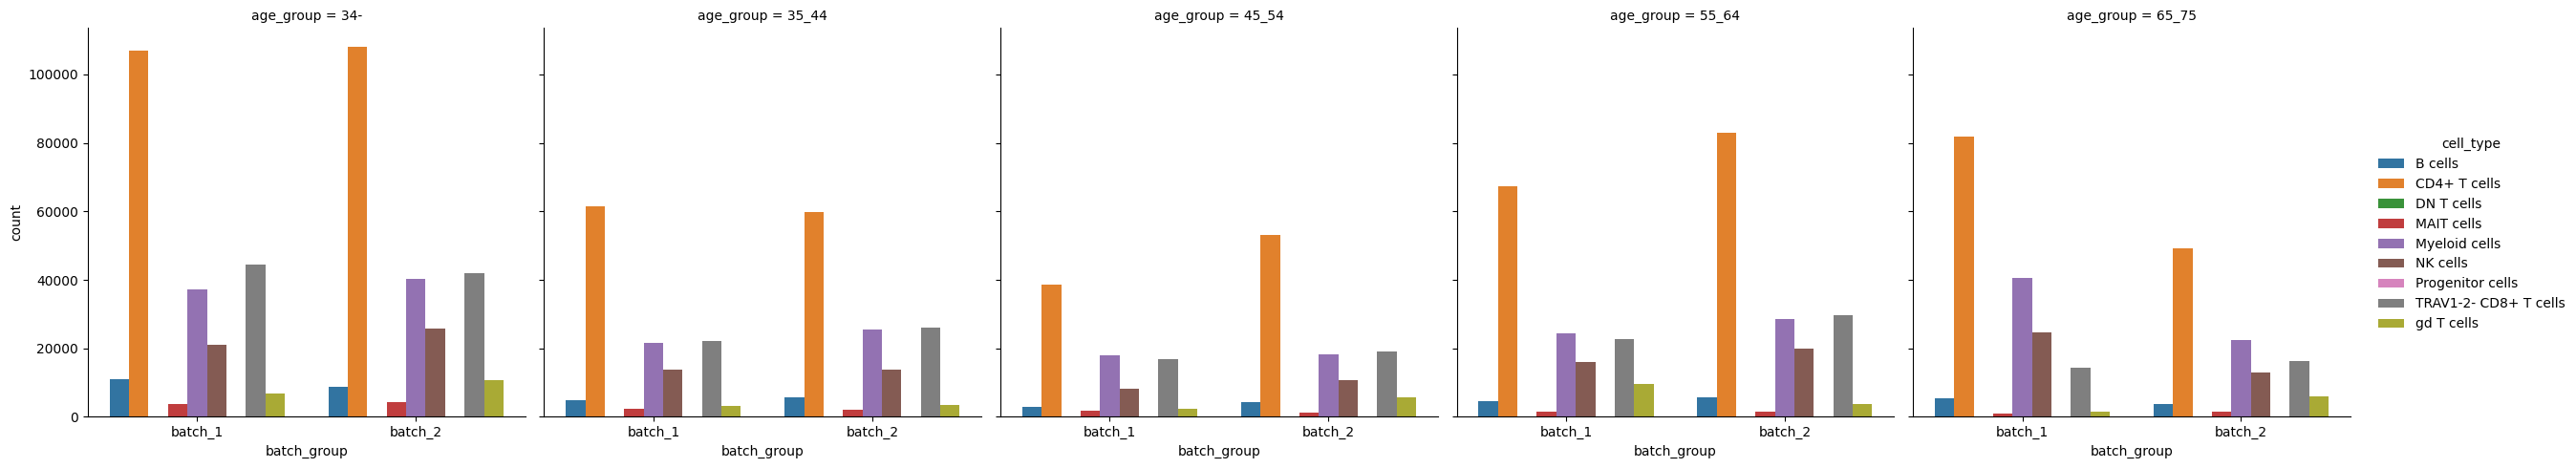

In [8]:
df_stats = obs.groupby(['batch_group', 'age_group','cell_type']).size().reset_index(name='count')
sns.catplot(df_stats, x='batch_group', y='count', hue='cell_type', kind='bar', col='age_group')

In [9]:
adata = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/initial_data_downloaded/pbmc_ageing/raw_counts_h5ad/pbmc_gex_raw_with_var_obs.h5ad')

for i, age_group in enumerate(obs['age_group'].unique()):
    obs_sub = obs[obs['age_group'] == age_group]
    adata_sub = adata[adata.obs.index.isin(obs_sub.index)]
    
    adata_sub = basic_qc(adata_sub, min_genes_per_cell = 200, max_genes_per_cell = 5000, min_cells_per_gene = 1000)
    
    if i == 0:
        adata_all = adata_sub
    else:
        adata_all = ad.concat([adata_sub, adata_all], axis=0, join="outer")
    print(adata_all)

shape before  (471423, 36601)
shape after  (471423, 14872)
View of AnnData object with n_obs × n_vars = 471423 × 14872
    obs: 'nCount_RNA', 'nFeature_RNA', 'Cluster_names'
    uns: 'Cluster_names_colors'
shape before  (281937, 36601)
shape after  (281937, 13658)
AnnData object with n_obs × n_vars = 753360 × 14877
    obs: 'nCount_RNA', 'nFeature_RNA', 'Cluster_names'
shape before  (318360, 36601)
shape after  (318360, 13747)
AnnData object with n_obs × n_vars = 1071720 × 14880
    obs: 'nCount_RNA', 'nFeature_RNA', 'Cluster_names'
shape before  (201629, 36601)
shape after  (201629, 12590)
AnnData object with n_obs × n_vars = 1273349 × 14881
    obs: 'nCount_RNA', 'nFeature_RNA', 'Cluster_names'
shape before  (266357, 36601)
shape after  (266357, 13320)
AnnData object with n_obs × n_vars = 1539706 × 14883
    obs: 'nCount_RNA', 'nFeature_RNA', 'Cluster_names'


In [10]:
adata_all.obs = adata_all.obs.merge(obs, left_index=True, right_index=True, how='left', suffixes=['','_'])
adata_all.obs = adata_all.obs[['batch', 'donor_id', 'age', 'cell_type', 'sex', 'age_donor', 'age_group', 'batch_group']]
adata_all.write('input/dataset_1_2.h5ad') 

In [12]:
if False:
    adata_all = ad.read_h5ad('input/dataset_1.h5ad') 
    obs = adata_all.obs
    obs_size = obs.groupby(['cell_type','age_group','batch_group']).size().reset_index(name='size')
    sns.catplot(obs_size, x='age_group', y='size', hue='batch_group', col='cell_type', kind='bar')

In [13]:
aa

NameError: name 'aa' is not defined

## Batch correction

In [6]:
if False:
    from src.helper import batch_correction
    batch_correction()
else:
    !srun --mem 350GB --time 2:00:00 python src/helper.py

srun: error: Unable to create step for job 7804343: Memory required by task is not available


## Evaluate batch correction

In [ ]:
# !sbatch scripts/sbatch/batch_correction_evaluation.sh

In [12]:
adata_all = ad.read_h5ad('input/dataset_1_corrected_batch1.h5ad') 

In [18]:
age_group = '34-'

mask_group = (adata_all.obs.age_group == age_group) & (adata_all.obs.batch_group=='batch_1')
adata_group = adata_all[mask_group]

corrected_n = sc.pp.normalize_total(adata_group, layer='counts', inplace=False)['X']
adata_group.layers['corrected_n'] = sc.pp.log1p(corrected_n, copy=True)

combat_corrected_n = sc.pp.normalize_total(adata_group, layer='combat_corrected', inplace=False)['X']
adata_group.layers['combat_corrected_n'] = sc.pp.log1p(combat_corrected_n, copy=True)

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


In [20]:
def plot_umap(adata_group, layer):
    sc.pp.pca(adata_group, layer=layer)
    sc.pp.neighbors(adata_group)
    sc.tl.umap(adata_group)
    sc.pl.umap(adata_group, color=['cell_type', 'donor_id'], wspace=.3)

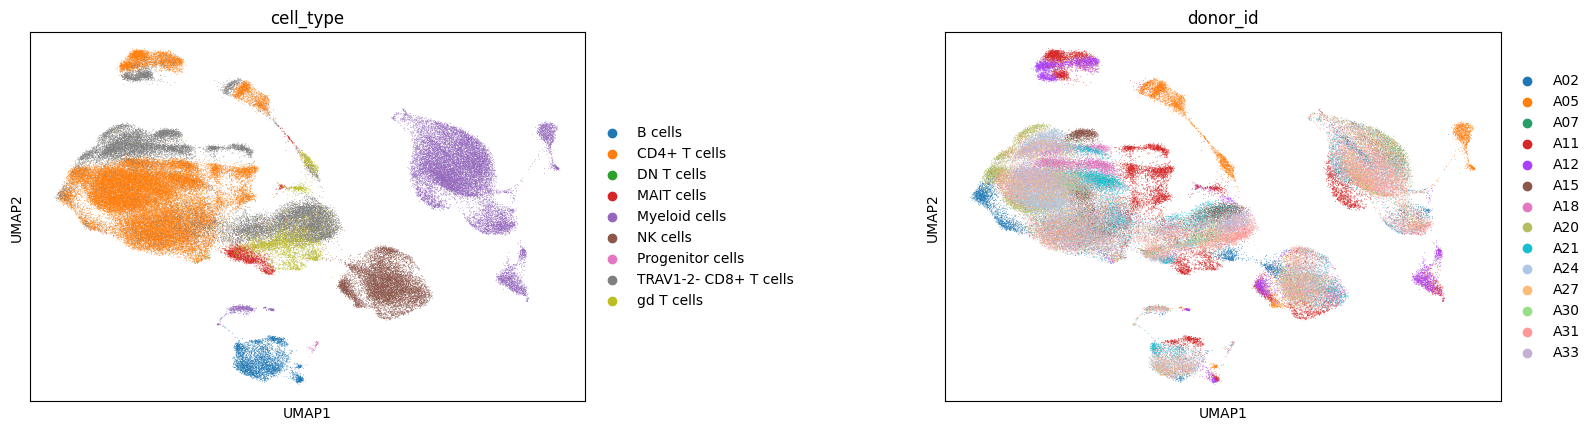

In [19]:
plot_umap(adata_group, 'corrected_n')

/home/jnourisa/miniconda3/envs/py10/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


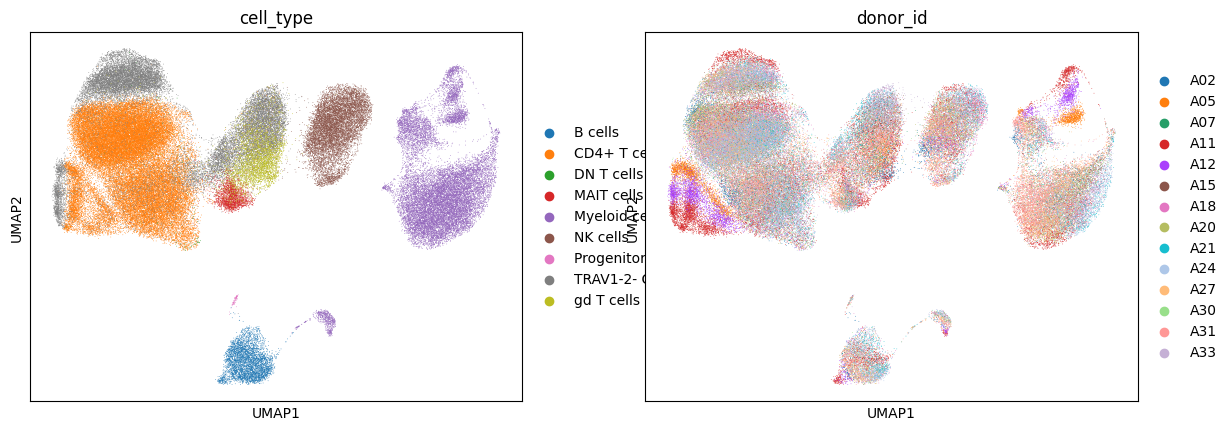

In [15]:
plot_umap(adata_group, 'combat_corrected_n')

# Dataset 2

In [1]:
!ls /vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/

data10_CMtx.h5ad      data2_var.csv	   data6_obs.csv
data10_CMtx.h5Seurat  data3_CMtx.h5ad	   data6_var.csv
data10_CMtx.rds       data3_CMtx.h5Seurat  data7_CMtx.h5ad
data10_obs.csv	      data3_CMtx.rds	   data7_CMtx.h5Seurat
data10_var.csv	      data3_obs.csv	   data7_CMtx.rds
data11_CMtx.h5ad      data3_var.csv	   data7_obs.csv
data11_CMtx.h5Seurat  data4_CMtx.h5ad	   data7_var.csv
data11_CMtx.rds       data4_CMtx.h5Seurat  data8_CMtx.h5ad
data11_obs.csv	      data4_CMtx.rds	   data8_CMtx.h5Seurat
data11_var.csv	      data4_obs.csv	   data8_CMtx.rds
data1_CMtx.h5ad       data4_var.csv	   data8_obs.csv
data1_CMtx.h5Seurat   data5_CMtx.h5ad	   data8_var.csv
data1_CMtx.rds	      data5_CMtx.h5Seurat  data9_CMtx.h5ad
data1_obs.csv	      data5_CMtx.rds	   data9_CMtx.h5Seurat
data1_var.csv	      data5_obs.csv	   data9_CMtx.rds
data2_CMtx.h5ad       data5_var.csv	   data9_obs.csv
data2_CMtx.h5Seurat   data6_CMtx.h5ad	   data9_var.csv
data2_CMtx.rds	      data6_CMtx.h5Seurat
data2_obs.csv	   

In [30]:
adata  = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/data1_CMtx.h5ad')
obs = adata.obs

obs = obs[['batch_info', 'donor_id','age','ct_major_published', 'sex']]
obs.columns = ['batch', 'donor_id', 'age', 'cell_type', 'sex']
obs['sex'] = obs['sex'].str.replace('M', 'Male')
obs['sex'] = obs['sex'].str.replace('F', 'Female')
obs['age_donor'] = obs['age'].astype(str) + '_' + obs['donor_id']

# - remove age over 75
obs = obs[obs.age<75]

# - binarize to age groups 
bins = [23, 35, 45, 55, 65, 75]  # Define bins for age groups
age_groups = ['34-', '35_44', '45_54', '55_64', '65_75']  # Define corresponding labels
obs['age_group'] = pd.cut(obs['age'], bins=bins, labels=age_groups, right=False)

/vol/tmp/users/jnourisa/ipykernel_3561361/2845241101.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs['sex'] = obs['sex'].str.replace('M', 'Male')
/vol/tmp/users/jnourisa/ipykernel_3561361/2845241101.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs['sex'] = obs['sex'].str.replace('F', 'Female')
/vol/tmp/users/jnourisa/ipykernel_3561361/2845241101.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value ins

In [32]:
obs['cell_type'] = obs['cell_type'].map(lambda name: cell_type_mapping.get(name,name))


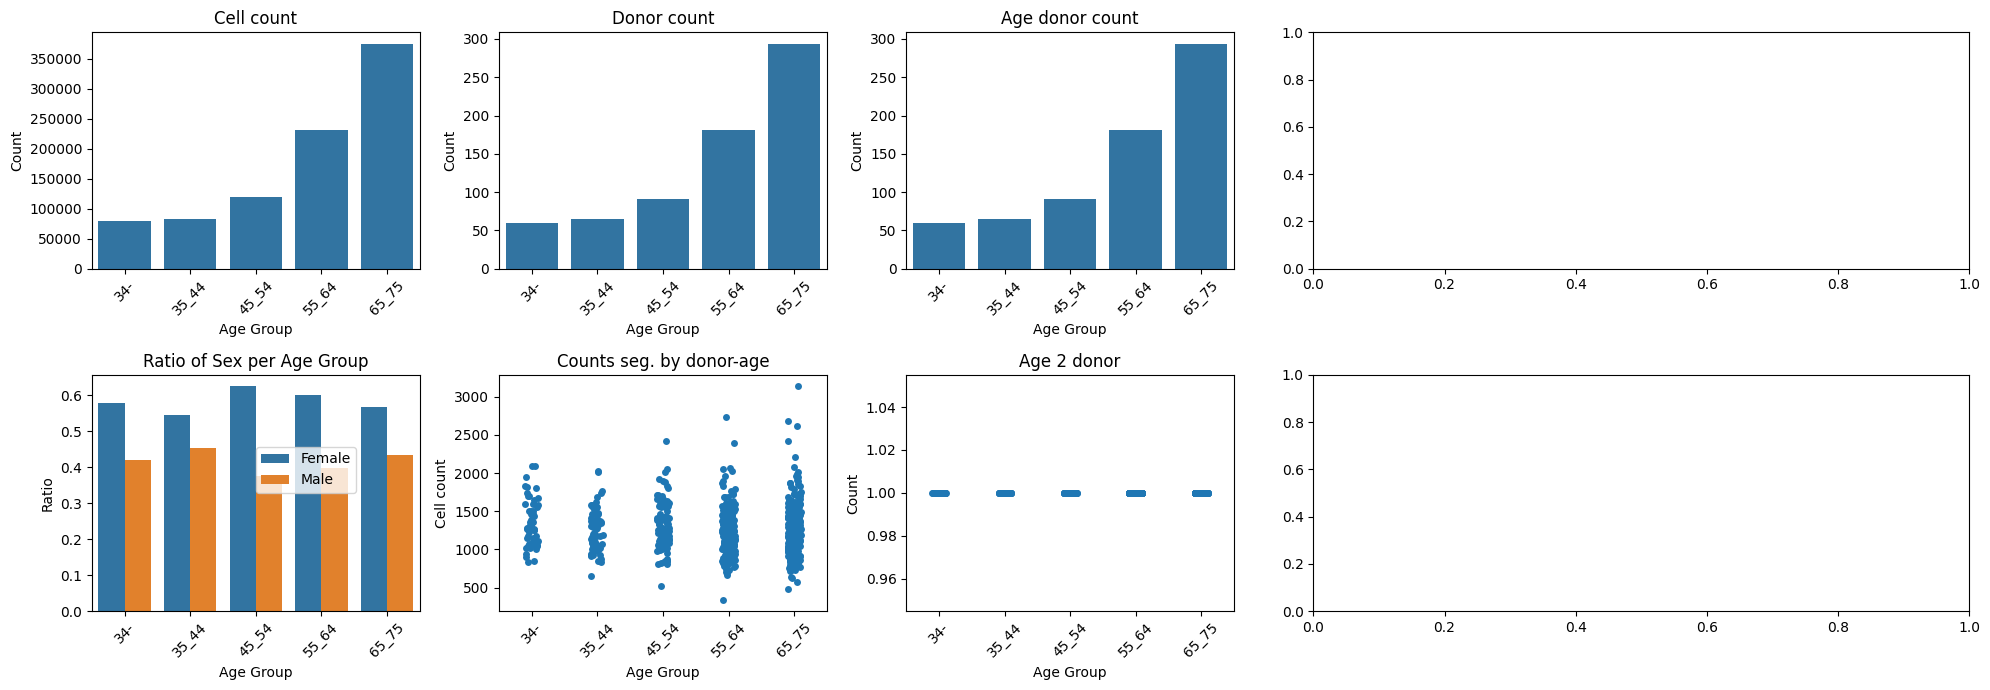

In [9]:
exp_plots(obs.groupby('age_group'), cell_type=False)

In [31]:
# - filter samples with low cell counts
n_cell_t = 1000

sample_size = obs.groupby('age_donor', as_index=False).size()
sample_size = sample_size[sample_size['size']>n_cell_t]

obs = obs[obs.age_donor.isin(sample_size.age_donor)]
# - filter for sex 
obs = obs[obs['sex']=='Male']

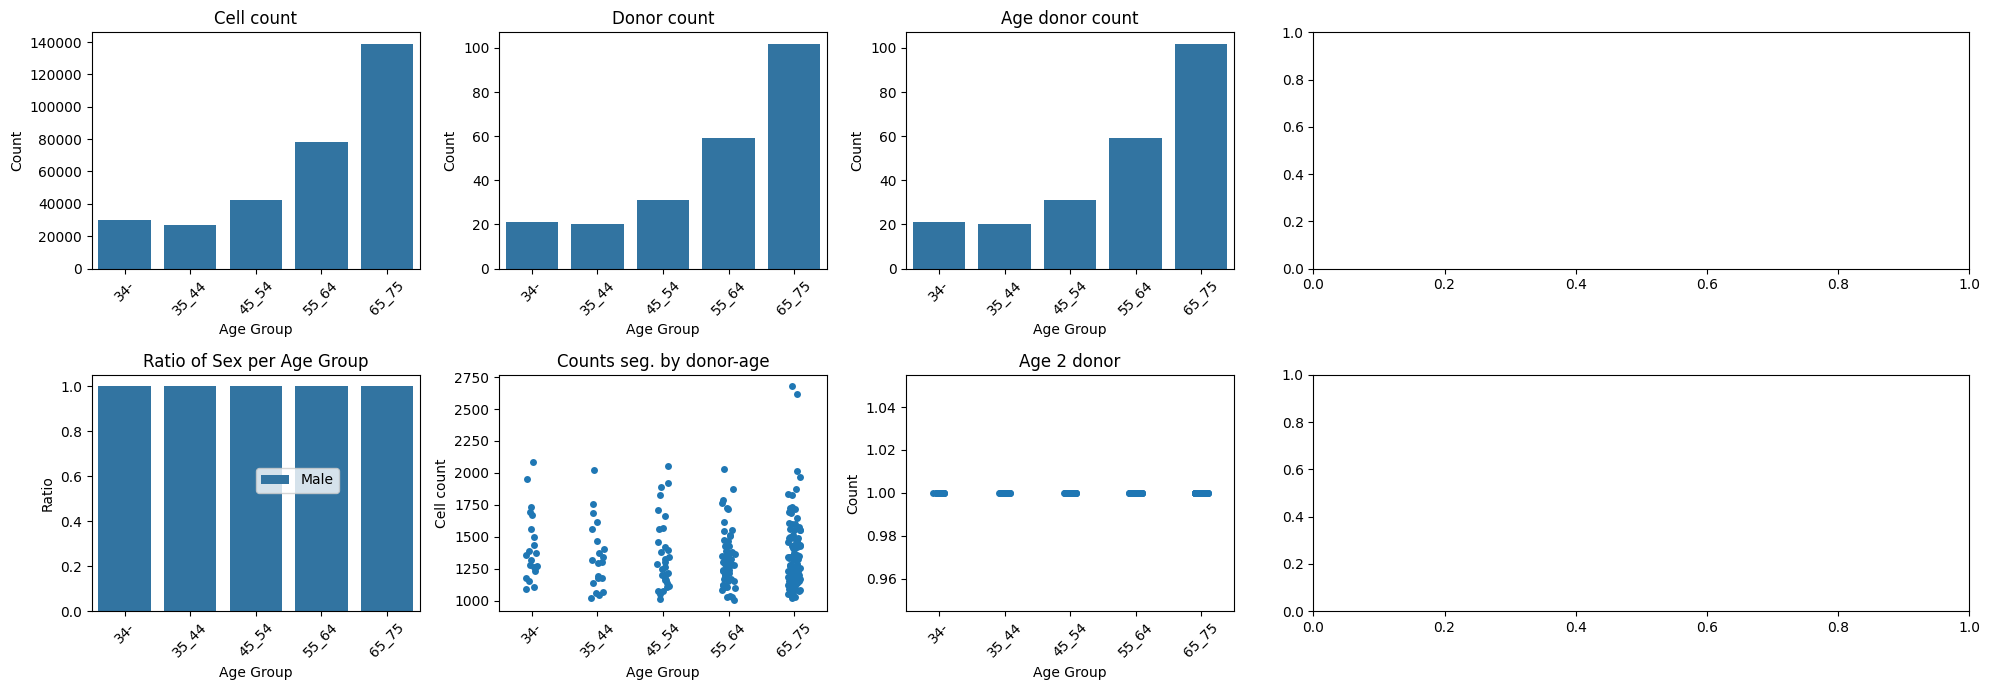

In [11]:
exp_plots(obs.groupby('age_group'), cell_type=False)

In [39]:
donor_size = 20
def reduce_donors(ss):
    if ss.nunique() >= donor_size:
        ss = np.random.choice(ss.unique(), size=donor_size, replace=False)
    else:
        pass
    return ss
# obs.groupby('age_group')['donor_id'].apply(reduce_donors)
donors_f = obs.groupby('age_group')['donor_id'].apply(reduce_donors)
obs = obs[obs.donor_id.isin(np.concatenate(donors_f.values))]
obs.shape

(137137, 7)

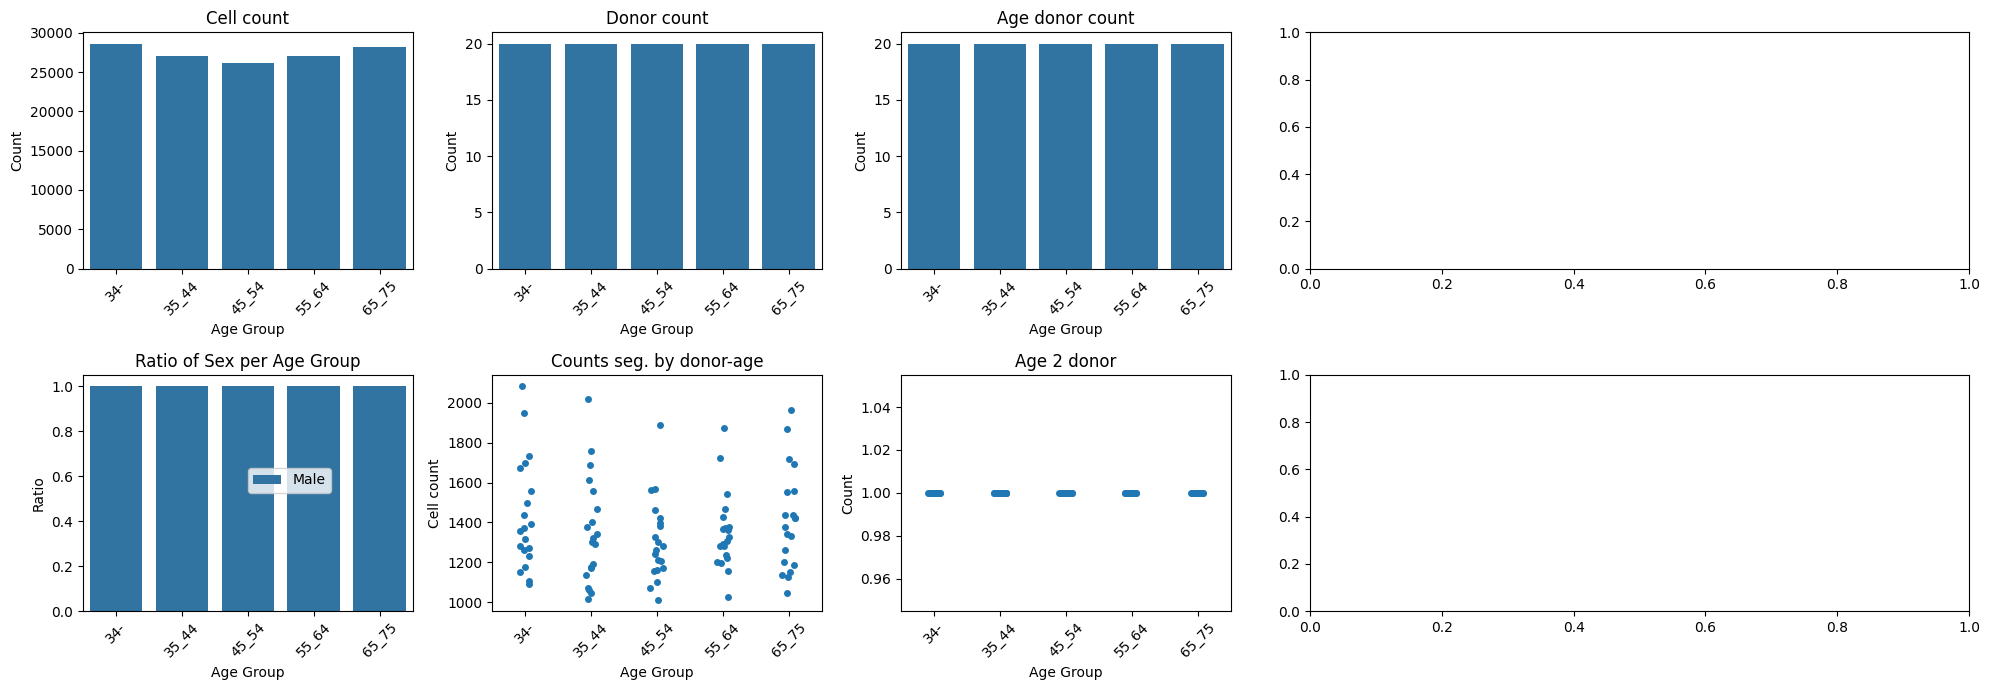

In [40]:
exp_plots(obs.groupby('age_group'), cell_type=False)

In [41]:
for i, age_group in enumerate(obs['age_group'].unique()):
    obs_sub = obs[obs['age_group'] == age_group]
    adata_sub = adata[adata.obs.index.isin(obs_sub.index)]
    
    adata_sub = basic_qc(adata_sub, min_genes_per_cell = 200, max_genes_per_cell = 5000, min_cells_per_gene = 1000)
    
    if i == 0:
        adata_all = adata_sub
    else:
        adata_all = ad.concat([adata_sub, adata_all], axis=0, join="outer")
    print(adata_all)
adata_all.obs = adata_all.obs.merge(obs, left_index=True, right_index=True, how='left', suffixes=['','_'])
adata_all.obs = adata_all.obs[['batch', 'donor_id', 'age', 'cell_type', 'sex', 'age_donor', 'age_group']]

adata_all.write('input/dataset_2.h5ad') 

shape before  (28234, 24281)
shape after  (28234, 5394)
View of AnnData object with n_obs × n_vars = 28234 × 5394
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'age', 'sex', 'batch_info', 'ct_major_published'
    var: 'features'
shape before  (27050, 24281)
shape after  (27048, 5385)
AnnData object with n_obs × n_vars = 55282 × 5507
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'age', 'sex', 'batch_info', 'ct_major_published'
shape before  (26194, 24281)
shape after  (26193, 5220)
AnnData object with n_obs × n_vars = 81475 × 5532
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'age', 'sex', 'batch_info', 'ct_major_published'
shape before  (28636, 24281)
shape after  (28635, 5155)
AnnData object with n_obs × n_vars = 110110 × 5554
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'donor_id', 'age', 'sex', 'batch_info', 'ct_major_published'
shape before  (27023, 24281)
shape after  (27023, 4985)
AnnData object with n_obs × n_vars 

# Dataset 1 and 2

In [2]:
def formatize_obs_1(obs):
    obs = obs[['Batch', 'Donor_id','Age','Cluster_names', 'Sex']]
    obs.columns = ['batch', 'donor_id', 'age', 'cell_type', 'sex']
    obs['age_donor'] = obs['age'].astype(str) + '_' + obs['donor_id']

    # - remove age over 75
    obs = obs[obs.age<=75]

    # - binarize to age groups 
    bins = [23, 35, 45, 55, 65, 76]  # Define bins for age groups
    age_groups = ['34-', '35_44', '45_54', '55_64', '65_75']  # Define corresponding labels
    obs['age_group'] = pd.cut(obs['age'], bins=bins, labels=age_groups, right=False)
    return obs

def formatize_obs_2(obs):
    obs = obs[['batch_info', 'donor_id','age','ct_major_published', 'sex']]
    obs.columns = ['batch', 'donor_id', 'age', 'cell_type', 'sex']
    obs['sex'] = obs['sex'].str.replace('M', 'Male')
    obs['sex'] = obs['sex'].str.replace('F', 'Female')
    obs['age_donor'] = obs['age'].astype(str) + '_' + obs['donor_id']

    # - remove age over 75
    obs = obs[obs.age<75]

    # - binarize to age groups 
    bins = [23, 35, 45, 55, 65, 75]  # Define bins for age groups
    age_groups = ['34-', '35_44', '45_54', '55_64', '65_75']  # Define corresponding labels
    obs['age_group'] = pd.cut(obs['age'], bins=bins, labels=age_groups, right=False)
    return obs

In [3]:
adata_1 = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/initial_data_downloaded/pbmc_ageing/raw_counts_h5ad/pbmc_gex_raw_with_var_obs.h5ad')
obs_1 = pd.read_csv('/vol/projects/CIIM/Healthy_Single_Cell_Data/initial_data_downloaded/pbmc_ageing/all_pbmcs/all_pbmcs_metadata.csv', index_col=0)
obs_1 = formatize_obs_1(obs_1)

/vol/tmp/users/jnourisa/ipykernel_76579/2767616881.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs['age_donor'] = obs['age'].astype(str) + '_' + obs['donor_id']


In [4]:
adata_2  = ad.read_h5ad('/vol/projects/CIIM/Healthy_Single_Cell_Data/count_matrix/data1_CMtx.h5ad')
obs_2 = adata_2.obs
obs_2 = formatize_obs_2(obs_2)


/vol/tmp/users/jnourisa/ipykernel_76579/2767616881.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs['sex'] = obs['sex'].str.replace('M', 'Male')
/vol/tmp/users/jnourisa/ipykernel_76579/2767616881.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  obs['sex'] = obs['sex'].str.replace('F', 'Female')
/vol/tmp/users/jnourisa/ipykernel_76579/2767616881.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instea

In [5]:
obs = pd.concat([obs_1, obs_2])
obs['cell_type'] = obs['cell_type'].map(lambda name: cell_type_mapping.get(name,name))

obs

,batch,donor_id,age,cell_type,sex,age_donor,age_group
ALAW-AS044-1_AAACCTGAGAAGCCCA-1,AS044,A20,27,CD4+ T cells,Male,27_A20,34-
ALAW-AS044-1_AAACCTGAGCAATCTC-1,AS044,A23,27,CD8+ T cells,Male,27_A23,34-
ALAW-AS044-1_AAACCTGCAATGTAAG-1,AS044,A15,26,CD4+ T cells,Male,26_A15,34-
ALAW-AS044-1_AAACCTGGTGCCTGCA-1,AS044,A23,27,CD8+ T cells,Male,27_A23,34-
ALAW-AS044-1_AAACCTGTCCAACCAA-1,AS044,A20,27,CD4+ T cells,Male,27_A20,34-
...,...,...,...,...,...,...,...
TTTGTCAGTCTAGCGC-9,Data1_9,Data1_794_795,39,B cells,Male,39_Data1_794_795,35_44
TTTGTCAGTGCACTTA-9,Data1_9,Data1_815_816,72,CD4+ T cells,Male,72_Data1_815_816,65_75
TTTGTCATCAGATAAG-9,Data1_9,Data1_799_800,70,CD8+ T cells,Male,70_Data1_799_800,65_75
TTTGTCATCCGCTGTT-9,Data1_9,Data1_796_797,64,B cells,Male,64_Data1_796_797,55_64


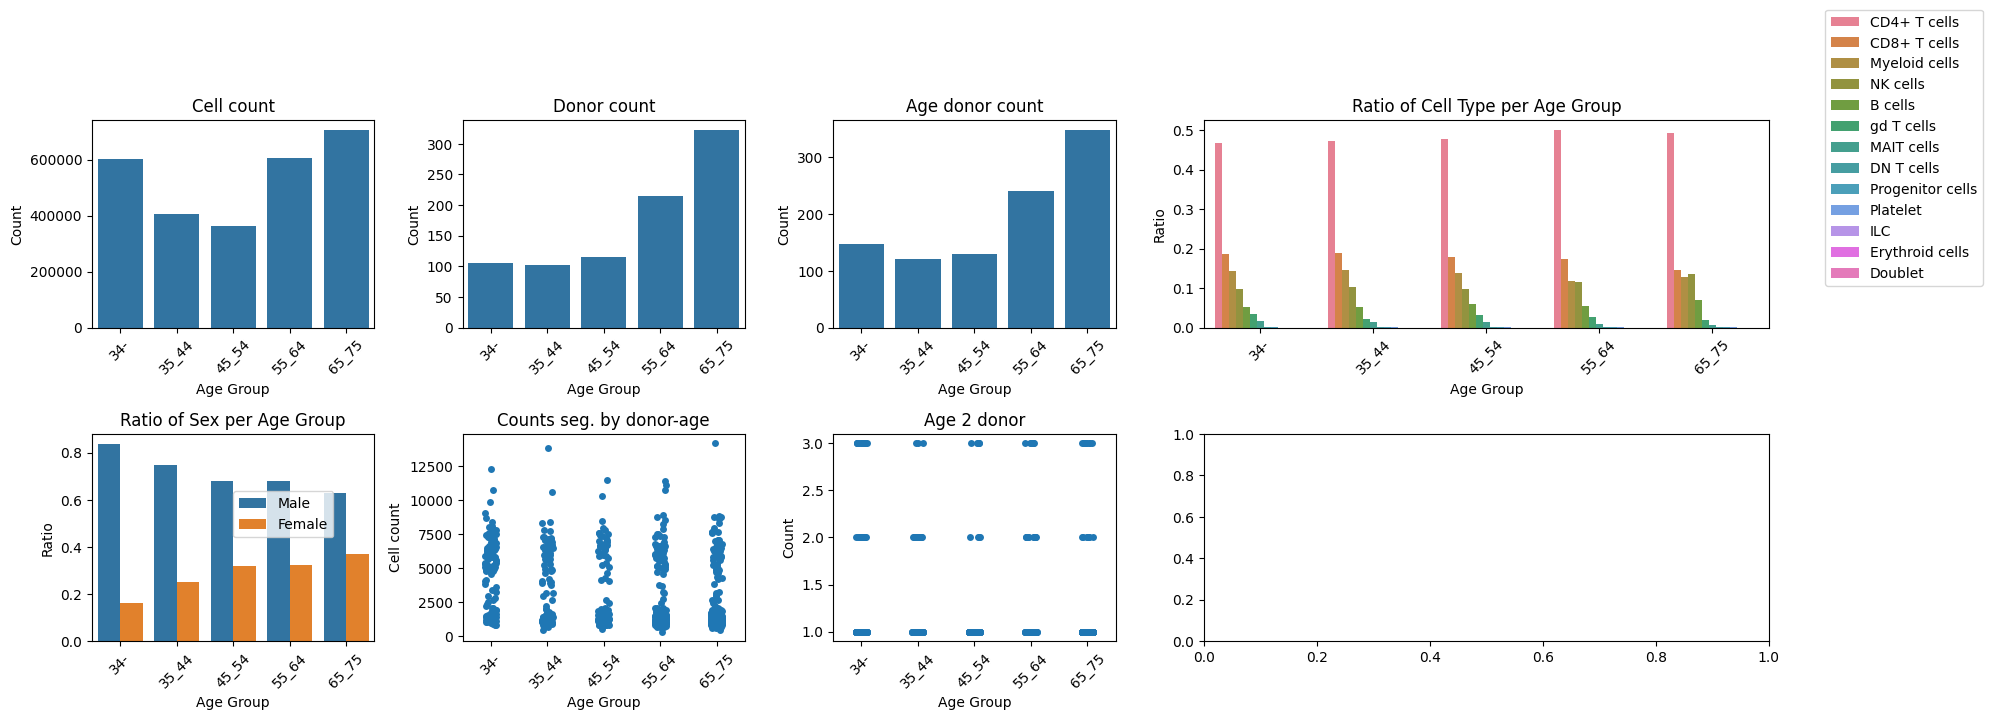

In [6]:
exp_plots(obs.groupby('age_group'), cell_type=True)

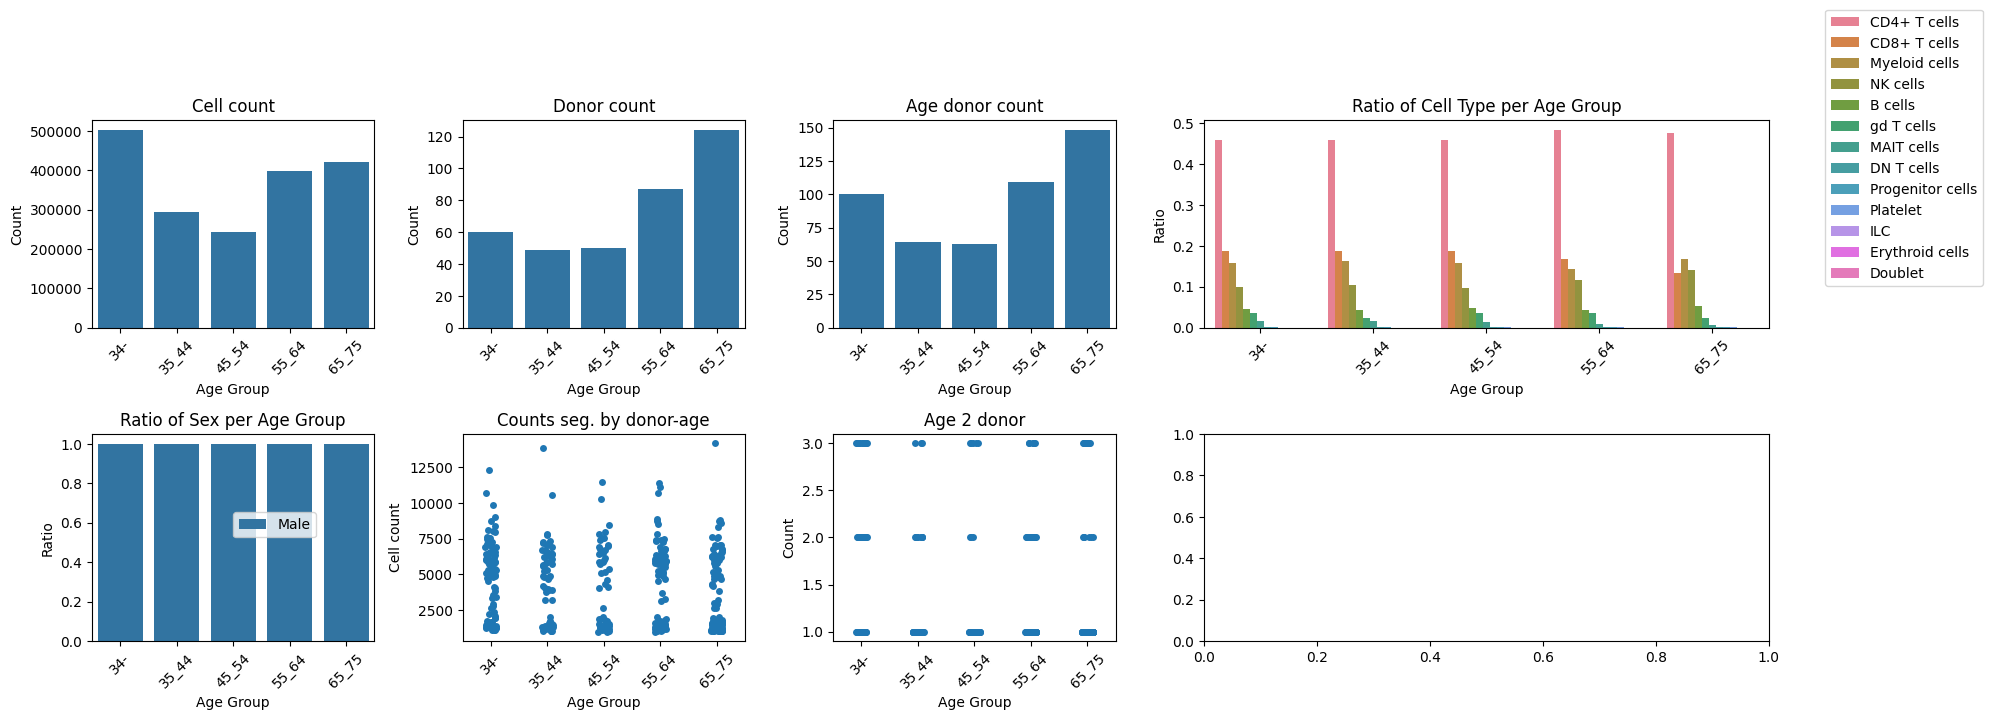

In [6]:
# - filter samples with low cell counts
n_cell_t = 1000

sample_size = obs.groupby('age_donor', as_index=False).size()
sample_size = sample_size[sample_size['size']>n_cell_t]

obs = obs[obs.age_donor.isin(sample_size.age_donor)]
# - filter for sex 
obs = obs[obs['sex']=='Male']
exp_plots(obs.groupby('age_group'), cell_type=True)

In [7]:
# - equalize donor size
donor_size = 60
def reduce_donors(ss):
    if ss.nunique() >= donor_size:
        ss = np.random.choice(ss.unique(), size=donor_size, replace=False)
    else:
        pass
    return ss
# obs.groupby('age_group')['donor_id'].apply(reduce_donors)
donors_f = obs.groupby('age_group')['donor_id'].apply(reduce_donors)
obs = obs[obs.donor_id.isin(np.concatenate(donors_f.values))]

In [8]:
def assign_batches(group):
    unique_donors = group['donor_id'].unique()
    np.random.shuffle(unique_donors)
    
    n_half = int(len(unique_donors) / 2)
    batch1 = unique_donors[:n_half]
    batch2 = unique_donors[n_half:]

    batch_names = ['batch_1'] * n_half + ['batch_2'] * (len(unique_donors) - n_half)
    map_donor_to_batch = {donor: batch for donor, batch in zip(unique_donors, batch_names)}
    group['batch_group'] = group['donor_id'].map(map_donor_to_batch)
    
    return group

obs = obs.groupby('age_group', group_keys=False).apply(assign_batches)
obs.shape

(1496358, 8)

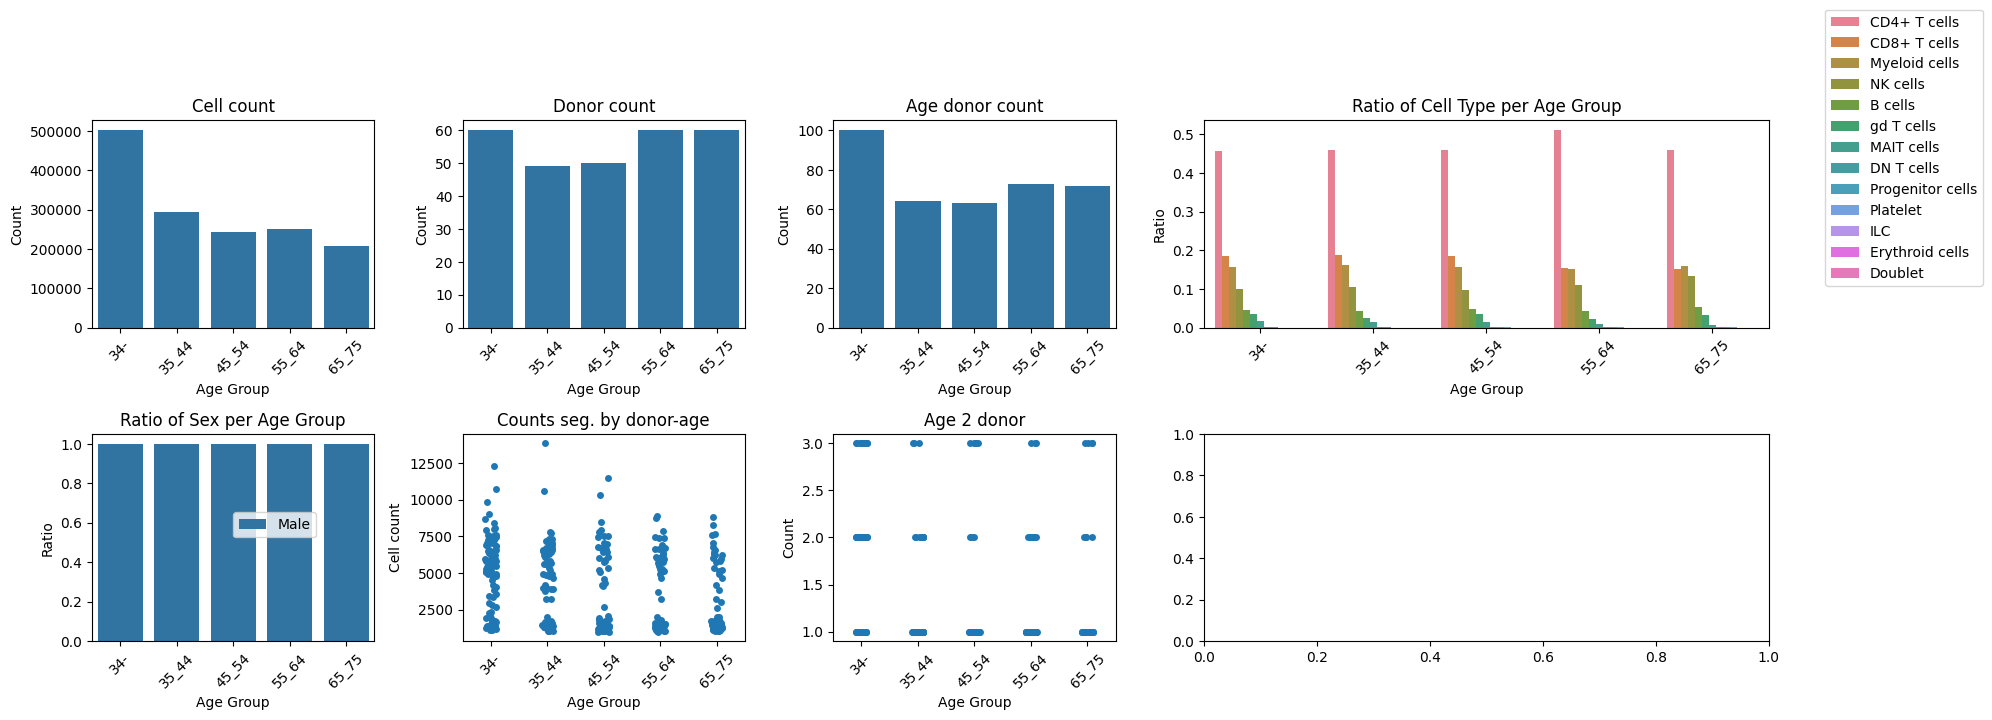

In [9]:
exp_plots(obs.groupby('age_group'), cell_type=True)

In [9]:
# - 
for i, age_group in enumerate(obs['age_group'].unique()):
    obs_sub = obs[obs['age_group'] == age_group]

    adata_1_sub = adata_1[adata_1.obs.index.isin(obs_sub.index), :]
    adata_2_sub = adata_2[adata_2.obs.index.isin(obs_sub.index), :]
    adata_sub = ad.concat([adata_1_sub, adata_2_sub], axis=0, join="outer")
    
    adata_sub = basic_qc(adata_sub, min_genes_per_cell = 200, max_genes_per_cell = 5000, min_cells_per_gene = 1000)
    
    if i == 0:
        adata_all = adata_sub
    else:
        adata_all = ad.concat([adata_sub, adata_all], axis=0, join="outer")
    print(adata_all)
adata_all.obs = adata_all.obs.merge(obs, left_index=True, right_index=True, how='left', suffixes=['','_'])
adata_all.obs = adata_all.obs[['batch', 'donor_id', 'age', 'cell_type', 'sex', 'age_donor', 'age_group']]

adata_all.write('input/dataset_12.h5ad') 

shape before  (501315, 38838)


shape after  (501314, 15055)
View of AnnData object with n_obs × n_vars = 501314 × 15055
    obs: 'nCount_RNA', 'nFeature_RNA', 'Cluster_names', 'orig.ident', 'donor_id', 'age', 'sex', 'batch_info', 'ct_major_published'
shape before  (270738, 38838)
shape after  (270736, 13285)
AnnData object with n_obs × n_vars = 772050 × 15156
    obs: 'nCount_RNA', 'nFeature_RNA', 'Cluster_names', 'orig.ident', 'donor_id', 'age', 'sex', 'batch_info', 'ct_major_published'
shape before  (243917, 38838)
shape after  (243912, 12948)
AnnData object with n_obs × n_vars = 1015962 × 15157
    obs: 'nCount_RNA', 'nFeature_RNA', 'Cluster_names', 'orig.ident', 'donor_id', 'age', 'sex', 'batch_info', 'ct_major_published'
shape before  (293380, 38838)
shape after  (293380, 13534)
